# Pilot Analysis — RBL-4 §7.3 (Tuần 7 deliverable)

**Owner:** MS — Tính mutation score trên pilot, xác nhận statistical test, ra quyết định go/no-go cho Tuần 8 (§7.4).

**Pilot là gì (đúng §7.1):** chạy thử trên một phần nhỏ dữ liệu (ở đây: 5,078/50,694 mutant ≈ 10% N — đúng khoảng
10–20% theo yêu cầu) **trước** khi scale lên full experiment ở Tuần 8. Data pilot (`data/pilot_sample.csv`,
`data/pilot_ground_truth.csv`, `results/pilot_llm_output.csv`, `results/pilot_gpt_selected.csv`,
`results/pilot_random_selected.csv`) là **data thật** copy từ pipeline LR (`LR/LR/`), không phải dữ liệu giả định.

**Nguyên tắc (proposal = hợp đồng, §6.5 HARKing prevention):** notebook này không đổi RQ/metric/threshold đã
duyệt, không tự tạo dữ liệu `killed` giả — cột `killed` lấy từ `data/pilot_ground_truth.csv` (ground truth PIT
thật, merge theo `mutant_id`, 100% mutant_id khớp — xem kiểm tra ở §7.3.0 dưới).

**Timeline:** notebook này = Tuần 7 (pilot, pool nhỏ hơn, chạy trước). Tuần 8 Full Experiment (pool đầy đủ
50,694 mutant) nằm ở `results/full_analysis.ipynb`, chạy sau khi pilot này đã pass gate §7.4.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import yaml

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "results" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

MIN_PAIRS_FOR_TEST = 10
EFFECT_SIZE_THRESHOLD = 0.30

print("OK — imports ready. PROJECT_ROOT =", PROJECT_ROOT)

OK — imports ready. PROJECT_ROOT = D:\K5-2026\SWT301\Presentation\RT-SWT-003-nhom3


In [2]:
data_dir = PROJECT_ROOT / "data"
results_dir = PROJECT_ROOT / "results"

df_pool = pd.read_csv(data_dir / "pilot_sample.csv")
df_gt = pd.read_csv(data_dir / "pilot_ground_truth.csv")
df_ranking = pd.read_csv(results_dir / "pilot_llm_output.csv")
df_gpt = pd.read_csv(results_dir / "pilot_gpt_selected.csv")
df_random = pd.read_csv(results_dir / "pilot_random_selected.csv")

df_gt["mutant_id"] = df_gt["mutant_id"].astype(str)
df_gt["killed"] = df_gt["killed"].astype(str).str.strip().str.lower().isin(["true", "1", "yes"])

print("Pilot mutant pool :", df_pool.shape)
print("Pilot ground truth:", df_gt.shape)
print("GPT ranking       :", df_ranking.shape)
print("GPT selected       :", df_gpt.shape)
print("Random selected    :", df_random.shape)

Pilot mutant pool : (5078, 10)
Pilot ground truth: (5078, 20)
GPT ranking       : (5078, 14)
GPT selected       : (508, 14)
Random selected    : (508, 10)


## 7.3.0 — Kiểm tra tính nhất quán pipeline (trước khi tin số liệu)

Theo §7.4 bảng quyết định: phải kiểm tra pipeline chạy đúng format trước khi diễn giải kết quả.

In [3]:
cfg = yaml.safe_load((PROJECT_ROOT.parent / "LR" / "LR" / "config.yaml").read_text(encoding="utf-8")) \
    if (PROJECT_ROOT.parent / "LR" / "LR" / "config.yaml").exists() else {"top_percent": 10}
top_percent = float(cfg.get("top_percent", 10))
expected_k = int(np.ceil(len(df_pool) * top_percent / 100.0))

def merge_killed(df):
    df = df.copy()
    df["mutant_id"] = df["mutant_id"].astype(str)
    merged = df.merge(df_gt[["mutant_id", "killed"]], on="mutant_id", how="left")
    return merged

df_gpt_k = merge_killed(df_gpt)
df_random_k = merge_killed(df_random)

checks = {
    "pool size matches ranking rows": len(df_pool) == len(df_ranking),
    "pool size matches ground truth rows (100% pilot pool co ground truth)": len(df_pool) == len(df_gt),
    f"GPT selected count == expected top {top_percent:.0f}% ({expected_k})": len(df_gpt) == expected_k,
    "Random selected count == GPT selected count": len(df_random) == len(df_gpt),
    "No null usefulness_score": int(df_ranking["usefulness_score"].isna().sum()) == 0,
    "No duplicate mutant_id in ranking": int(df_ranking["mutant_id"].duplicated().sum()) == 0,
    "All GPT-selected mutant_id found in ground truth": int(df_gpt_k["killed"].isna().sum()) == 0,
    "All random-selected mutant_id found in ground truth": int(df_random_k["killed"].isna().sum()) == 0,
}

for name, passed in checks.items():
    print(("PASS" if passed else "FAIL"), "-", name)

all_passed = all(checks.values())
print("\nAll pipeline-consistency checks passed:", all_passed)

PASS - pool size matches ranking rows
PASS - pool size matches ground truth rows (100% pilot pool co ground truth)
PASS - GPT selected count == expected top 10% (508)
PASS - Random selected count == GPT selected count
PASS - No null usefulness_score
PASS - No duplicate mutant_id in ranking
PASS - All GPT-selected mutant_id found in ground truth
PASS - All random-selected mutant_id found in ground truth

All pipeline-consistency checks passed: True


## 7.3.1 — Phân phối `usefulness_score` (histogram — đúng yêu cầu §7.3 bullet 2)

Đây là điểm GPT4o-mini gán cho mỗi mutant (1–5), KHÔNG phải mutation score.

usefulness_score
1     244
2     407
3      11
4    2048
5    2368
Name: count, dtype: int64

Mean usefulness_score: 4.16


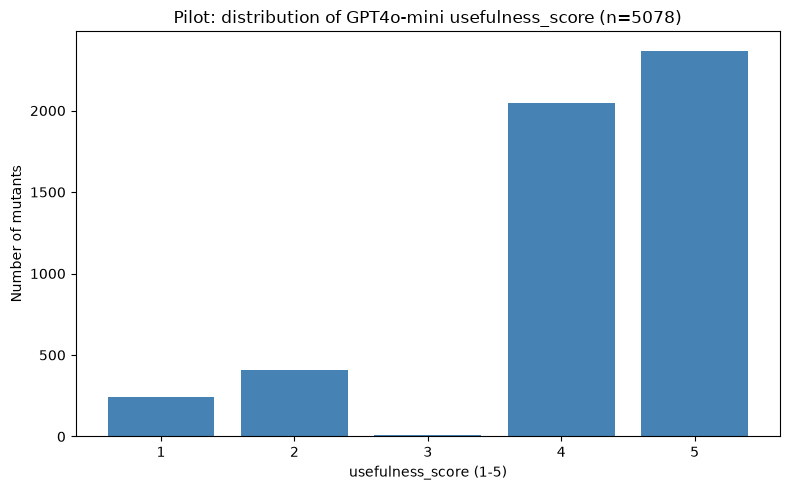

In [4]:
score_counts = df_ranking["usefulness_score"].value_counts().sort_index()
print(score_counts)
print("\nMean usefulness_score:", round(df_ranking["usefulness_score"].mean(), 2))

plt.figure(figsize=(8, 5))
plt.bar(score_counts.index, score_counts.values, color="steelblue")
plt.title(f"Pilot: distribution of GPT4o-mini usefulness_score (n={len(df_ranking)})")
plt.xlabel("usefulness_score (1-5)")
plt.ylabel("Number of mutants")
plt.tight_layout()
plt.savefig(results_dir / "pilot_score_distribution.png", dpi=300)
plt.show()

**Nhận xét phân phối (§7.3 bullet 3 — xác nhận lại lựa chọn statistical test):** phân phối lệch mạnh về
điểm 4–5 (rời rạc 1–5, không phải liên tục/chuẩn) — đúng như dự kiến cho một thang đánh giá LLM 5 mức, không
có gì bất thường buộc phải đổi test. **Giữ nguyên** statistical test đã chọn trong proposal: Wilcoxon
signed-rank một phía (nonparametric, phù hợp cho paired mutation-score, không giả định phân phối chuẩn).

## 7.3.2 — Coverage theo project (Commons Lang vs Commons Math)

Kiểm tra trước khi tính RQ1: cả 2 project có mặt ở cả 2 nhánh GPT/random không?

In [5]:
print("Pool theo project:")
print(df_pool["project"].value_counts())
print("\nGPT selected theo project:")
print(df_gpt["project"].value_counts())
print("\nRandom selected theo project:")
print(df_random["project"].value_counts())

gpt_projects = set(df_gpt["project"].unique())
missing_from_gpt = set(df_pool["project"].unique()) - gpt_projects
if missing_from_gpt:
    print(f"\n[BUG PHÁT HIỆN Ở PILOT] GPT selection không chọn mutant nào từ: {missing_from_gpt}.")
    print("Nguyên nhân: pipeline pilot (LR/LR/scripts/run_pipeline.py) chọn top-10% theo TOÀN BỘ pool")
    print("(global sort theo usefulness_score, tie-break theo mutant_id alphabet) — không sort theo từng group")
    print("(project/version/class_name). Vì usefulness_score chỉ có 5 mức rời rạc nên tie ở điểm cao nhất rất")
    print("nhiều, và project có mutant_id đứng trước alphabet ('Lang_...') luôn thắng project đứng sau")
    print("('Math_...') trong tie-break — giống lỗi Bug 1 đã ghi nhận cho full experiment ở notes.md.")
else:
    print("\n[OK] Cả 2 project đều có mutant được GPT chọn.")

Pool theo project:
project
Lang    4777
Math     301
Name: count, dtype: int64

GPT selected theo project:
project
Lang    508
Name: count, dtype: int64

Random selected theo project:
project
Lang    485
Math     23
Name: count, dtype: int64

[BUG PHÁT HIỆN Ở PILOT] GPT selection không chọn mutant nào từ: {'Math'}.
Nguyên nhân: pipeline pilot (LR/LR/scripts/run_pipeline.py) chọn top-10% theo TOÀN BỘ pool
(global sort theo usefulness_score, tie-break theo mutant_id alphabet) — không sort theo từng group
(project/version/class_name). Vì usefulness_score chỉ có 5 mức rời rạc nên tie ở điểm cao nhất rất
nhiều, và project có mutant_id đứng trước alphabet ('Lang_...') luôn thắng project đứng sau
('Math_...') trong tie-break — giống lỗi Bug 1 đã ghi nhận cho full experiment ở notes.md.


## 7.3.3 — RQ1 Primary Metric: Mutation Score (Killed / Selected) trên pilot

```
Mutation Score = Killed Mutants / Selected Mutants
MS_GPT4o   = mutation score của GPT4o-mini-selected mutants (pilot)
MS_random  = mutation score của random fixed-seed-selected mutants (pilot)
```

In [6]:
ms_gpt = df_gpt_k["killed"].mean()
ms_random = df_random_k["killed"].mean()
print(f"MS_GPT4o   = {ms_gpt:.4f}  ({int(df_gpt_k['killed'].sum())}/{len(df_gpt_k)} killed)")
print(f"MS_random  = {ms_random:.4f}  ({int(df_random_k['killed'].sum())}/{len(df_random_k)} killed)")

MS_GPT4o   = 0.8996  (457/508 killed)
MS_random  = 0.8406  (427/508 killed)


## 7.3.4 — Paired analysis theo (project, version, class_name) + Wilcoxon signed-rank

Paired theo project/version/class_name (proposal §5.6). Wilcoxon signed-rank một phía, α=0.05
(H1: MS_GPT4o > MS_random), effect size = matched-pairs rank-biserial (ngưỡng r_rb ≥ 0.30, §6.1).

**Lưu ý quan trọng:** vì GPT selection ở pilot này không chọn mutant nào từ Commons Math (xem §7.3.2),
paired analysis theo cách inner-join giữa 2 nhánh GPT/random **chỉ có group từ Commons Lang** — không đại
diện đầy đủ cho cả 2 project. Đây là hạn chế cần ghi nhận, không phải kết luận cuối cùng cho toàn bộ pool.

In [7]:
GROUP_COLS = ["project", "version", "class_name"]

def group_mutation_score(df, label):
    g = df.groupby(GROUP_COLS, dropna=False).agg(
        selected=("mutant_id", "count"),
        killed=("killed", "sum"),
    )
    g[f"ms_{label}"] = g["killed"] / g["selected"]
    return g.rename(columns={"selected": f"selected_{label}", "killed": f"killed_{label}"})

g_gpt = group_mutation_score(df_gpt_k, "gpt")
g_random = group_mutation_score(df_random_k, "random")
paired = g_gpt.join(g_random, how="inner").reset_index()
paired.to_csv(results_dir / "pilot_paired_mutation_scores.csv", index=False, encoding="utf-8")

print("Số paired unit (project/version/class_name):", len(paired))
print(paired["project"].value_counts())

diff = (paired["ms_gpt"] - paired["ms_random"]).to_numpy()
n_pairs = len(diff)
nz = diff[diff != 0]
n_nonzero = len(nz)

print(f"\nn_pairs={n_pairs}, n_nonzero={n_nonzero}, n_ties={n_pairs - n_nonzero}")
print("win_gpt:", int((diff > 0).sum()), "| win_random:", int((diff < 0).sum()), "| tie:", int((diff == 0).sum()))

if n_nonzero >= MIN_PAIRS_FOR_TEST:
    stat, p_value = wilcoxon(diff, alternative="greater", zero_method="wilcox")
    ranks = pd.Series(np.abs(nz)).rank(method="average").to_numpy()
    w_pos = ranks[nz > 0].sum()
    w_neg = ranks[nz < 0].sum()
    r_rb = float((w_pos - w_neg) / (n_nonzero * (n_nonzero + 1) / 2))
    print(f"\nWilcoxon signed-rank (one-sided, H1: MS_GPT4o > MS_random): p={p_value:.6f}, r_rb={r_rb:.4f}")

    print("\nDiễn giải theo §6.2:")
    if p_value < 0.05 and r_rb >= EFFECT_SIZE_THRESHOLD:
        print(f"→ Case 1: p={p_value:.6f} < 0.05 VÀ r_rb={r_rb:.4f} >= 0.30 — ỦNG HỘ H1 (chỉ trên phần Commons Lang có trong pilot).")
    elif p_value < 0.05:
        print("→ Case 2: p<0.05 nhưng effect size nhỏ — KHÔNG kết luận H1.")
    else:
        print("→ Case 3/4: p>=0.05 — KHÔNG kết luận H1.")
else:
    print(f"\nn_nonzero={n_nonzero} < {MIN_PAIRS_FOR_TEST}: mẫu pilot quá nhỏ để chạy Wilcoxon đáng tin cậy — chỉ descriptive.")

Số paired unit (project/version/class_name): 41
project
Lang    41
Name: count, dtype: int64

n_pairs=41, n_nonzero=15, n_ties=26
win_gpt: 11 | win_random: 4 | tie: 26

Wilcoxon signed-rank (one-sided, H1: MS_GPT4o > MS_random): p=0.008474, r_rb=0.7000

Diễn giải theo §6.2:
→ Case 1: p=0.008474 < 0.05 VÀ r_rb=0.7000 >= 0.30 — ỦNG HỘ H1 (chỉ trên phần Commons Lang có trong pilot).


## 7.4 — Quyết định sau pilot

Theo bảng quyết định RBL-4 §7.4:

In [8]:
print("=== Tổng hợp kết quả pilot (Tuần 7) ===")
print(f"MS_GPT4o (pilot)  = {ms_gpt:.4f} ({int(df_gpt_k['killed'].sum())}/{len(df_gpt_k)})")
print(f"MS_random (pilot) = {ms_random:.4f} ({int(df_random_k['killed'].sum())}/{len(df_random_k)})")
print(f"Paired groups     = {len(paired)} (toàn bộ đều là Commons Lang — Math bị loại do bug selection)")
print(f"Wilcoxon (Lang)   = p={p_value:.6f}, r_rb={r_rb:.4f} -> {'ỦNG HỘ H1' if (p_value < 0.05 and r_rb >= EFFECT_SIZE_THRESHOLD) else 'KHÔNG kết luận H1'}")
print(f"GPT coverage Math = {int((df_gpt['project'] == 'Math').sum())} / {int((df_pool['project'] == 'Math').sum())} mutant Math trong pool")

=== Tổng hợp kết quả pilot (Tuần 7) ===
MS_GPT4o (pilot)  = 0.8996 (457/508)
MS_random (pilot) = 0.8406 (427/508)
Paired groups     = 41 (toàn bộ đều là Commons Lang — Math bị loại do bug selection)
Wilcoxon (Lang)   = p=0.008474, r_rb=0.7000 -> ỦNG HỘ H1
GPT coverage Math = 0 / 301 mutant Math trong pool


**Đối chiếu với bảng quyết định §7.4:**

| Kết quả pilot quan sát được | Dòng áp dụng trong bảng §7.4 | Hành động |
|---|---|---|
| Pipeline chạy đúng format, output đúng cấu trúc (§7.3.0 — tất cả check PASS) | "Pipeline chạy đúng, format output đúng" | Có thể tiến hành Tuần 8 |
| GPT selection chọn 0 mutant từ Commons Math (§7.3.2) — lỗi tie-break do sort global theo `usefulness_score` | "Lỗi kỹ thuật nhỏ (format output, script bug)" | **LR sửa trong ngày, không cần amendment** (đây là lỗi selection script, không phải đổi RQ/metric/threshold — không vi phạm §6.5) |
| Phân phối `usefulness_score` lệch về 4-5 nhưng không bất thường (§7.3.1) | "Phân phối như dự kiến" | Giữ nguyên statistical test đã chọn trong proposal (Wilcoxon signed-rank một phía) |

**Quyết định:** Tiến hành Tuần 8 Full Experiment, **với điều kiện** sửa lỗi selection trước khi chạy full —
chọn top-`top_percent`% theo **từng group** (project, version, class_name) thay vì theo toàn bộ pool, để tránh
Commons Math bị loại hoàn toàn ở quy mô lớn hơn. (Đây chính là fix `selection_scope: by_group` +
`scripts/reselect_by_group.py` đã áp dụng cho Tuần 8 — xem `config.yaml` và `notes.md` Bug 1 trong repo này;
pilot ở đây là nơi đầu tiên phát hiện ra lỗi này bằng dữ liệu thật, trước khi nó lặp lại ở quy mô full.)

**Không kết luận RQ1 chính thức từ pilot này** — n mẫu nhỏ (508 selected/nhánh, chỉ 15 paired-group khác 0 sau
khi loại tie) và thiếu hoàn toàn Commons Math ở nhánh GPT. Kết luận RQ1 chính thức nằm ở `results/full_analysis.ipynb`
(Tuần 8, sau khi đã sửa bug selection).